In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib
from sklearn.preprocessing import LabelEncoder
import pickle

In [4]:
# Load Dataset 1
SoilDataSet = pd.read_csv('Soil.csv')

# Load Dataset 2
RainfallDataSet = pd.read_csv('Rainfall.csv')

# Load Dataset 3


In [5]:

def get_soil_parameters(location, dataset):
    # Filter dataset_1 for the given location
    location_data = dataset[dataset['District'] == location]

    if location_data.empty:
        print(f"No data found for {location}.")
        return None

    # Extracting soil parameters
    n_level = location_data['Nitrogen'].values[0]
    k_level = location_data['Potassium'].values[0]
    p_level = location_data['Phosphorous'].values[0]
    ph_level = location_data['pH'].values[0]

    return n_level, k_level, p_level, ph_level

# Example usage:
location_input = input("Enter the Location: ")
month_input = input("Enter the Month: ")
year_input = int(input("Enter the Year: "))
temperature_input = float(input("Enter temperature: "))
humidity_input = float(input("Enter humidity: "))

# Get soil parameters for the location
n, k, p, ph = get_soil_parameters(location_input, SoilDataSet)
if n is not None:
    print(f"User Inputs - Location: {location_input}, Temperature: {temperature_input}, Humidity: {humidity_input}")
    print(f"Corresponding Soil Parameters - Nitrogen: {n}, Potassium: {k}, Phosphorous: {p}, pH: {ph}")
else:
    print("Failed to fetch soil parameters.")

User Inputs - Location: Ramanathapuram, Temperature: 40.0, Humidity: 82.0
Corresponding Soil Parameters - Nitrogen: 128.5, Potassium: 269.0, Phosphorous: 24.0, pH: 7.2


In [6]:
# Read the CSV file
file_path = 'Rainfall.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Function to predict rainfall for a given month and year
def predict_rainfall_for_month(month, year):
    # Mapping months to seasons
    months_to_season = {
        'January': 'WINTER SEASON',
        'February': 'WINTER SEASON',
        'March': 'SUMMER SEASON',
        'April': 'SUMMER SEASON',
        'May': 'SUMMER SEASON',
        'June': 'SOUTH-WESTMONSOON',
        'July': 'SOUTH-WESTMONSOON',
        'August': 'SOUTH-WESTMONSOON',
        'September': 'NORTH-EASTMONSOON',
        'October': 'NORTH-EASTMONSOON',
        'November': 'NORTH-EASTMONSOON',
        'December': 'WINTER SEASON'
    }
    
    season = months_to_season[month]

    # Extracting columns for the specified season
    season_data = data.filter(regex=f'^{season}')

    # Taking the second row as column names
    column_names = season_data.iloc[0].tolist()

    # Selecting data rows and setting proper column names
    season_data = season_data[2:]
    season_data.columns = column_names

    X = season_data.index.values.reshape(-1, 1)
    y = season_data['Normal'].values

    # Splitting the data for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model initialization and fitting (Random Forest)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predicting rainfall for the next pseudo-year
    next_year = season_data.index.max() + 1
    predicted_rainfall_rf = rf_model.predict([[next_year]])

    # Evaluating model accuracy
    predictions = rf_model.predict(X_test)
    accuracy = r2_score(y_test, predictions)

    print(f"Predicted rainfall for {season} of {year}: {predicted_rainfall_rf[0]:.2f} mm")
    print(f"Model accuracy: {accuracy:.2f}")

    return predicted_rainfall_rf[0]

# Example usage:
rainfall_input = predict_rainfall_for_month(month_input, year_input)
print(rainfall_input)



Predicted rainfall for NORTH-EASTMONSOON of 2024: 449.56 mm
Model accuracy: 0.76
449.55600000000004


In [7]:
file_path2 = 'Crop.csv'  # Replace with your file path
data2 = pd.read_csv(file_path2)

# Define features and target variable
features = ['Nitrogen', 'Potassium', 'Phosphorous', 'pH', 'Temperature', 'Humidity', 'Rainfall']
target = 'Final_Crop'

label_mapping = {
    'rice': 0, 'maize': 1, 'chickpea': 2, 'kidneybeans': 3, 'pigeonpeas': 4,
    'mothbeans': 5, 'mungbean': 6, 'blackgram': 7, 'lentil': 8, 'pomegranate': 9,
    'banana': 10, 'mango': 11, 'grapes': 12, 'watermelon': 13, 'muskmelon': 14,
    'apple': 15, 'orange': 16, 'papaya': 17, 'coconut': 18, 'cotton': 19,
    'jute': 20, 'coffee': 21
}

# Map crop names to numerical labels in your dataset
data2[target] = data2[target].map(label_mapping)
X = data2[features]
y = data2[target]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


# Model initialization (XGBoost)
model = XGBClassifier()

# Model training
model.fit(X_train, y_train)

# Predicting on the test set
y_pred = model.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy}")

# Save the model to a file
model_file_path = 'xgboost_crop_model.pkl'  # Replace with your desired file path
#joblib.dump(model, model_file_path)


Model accuracy: 0.996969696969697


In [8]:
with open('xgboost_crop_model.pkl', 'rb') as file:
    xgboost_model = pickle.load(file)

# Define the input parameters for prediction
input_parameters = [
    n, k, p, ph, temperature_input, humidity_input, rainfall_input # Replace these values with your input parameters
]
# Reshape the input parameters
input_parameters = [input_parameters]



# Predict the crop using the loaded model
predicted_crop = xgboost_model.predict(input_parameters)


label_mapping = {
    0: 'rice', 1: 'maize', 2: 'chickpea', 3: 'kidneybeans', 4: 'pigeonpeas',
    5: 'mothbeans', 6: 'mungbean', 7: 'blackgram', 8: 'lentil', 9: 'pomegranate',
    10: 'banana', 11: 'mango', 12: 'grapes', 13: 'watermelon', 14: 'muskmelon',
    15: 'apple', 16: 'orange', 17: 'papaya', 18: 'coconut', 19: 'cotton',
    20: 'jute', 21: 'coffee'
}

# Using your model prediction result
predicted_crop_name = label_mapping[predicted_crop[0]]
print(f"The predicted crop is: {predicted_crop_name}")


The predicted crop is: jute


In [9]:
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry

In [10]:
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 13.0878,
	"longitude": 80.2785,
	"current": ["temperature_2m", "relative_humidity_2m"]
}
responses = openmeteo.weather_api(url, params=params)


ConnectionError: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Max retries exceeded with url: /v1/forecast?latitude=13.0878&longitude=80.2785&current=temperature_2m&current=relative_humidity_2m&format=flatbuffers (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001A8DC01F590>: Failed to resolve 'api.open-meteo.com' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°E {response.Longitude()}°N")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Current values. The order of variables needs to be the same as requested.
current = response.Current()
current_temperature_2m = current.Variables(0).Value()
current_relative_humidity_2m = current.Variables(1).Value()

print(f"Current time {current.Time()}")
print(f"Current temperature_2m {current_temperature_2m}")
print(f"Current relative_humidity_2m {current_relative_humidity_2m}")

Coordinates 13.0°E 80.125°N
Elevation 15.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s
Current time 1700540100
Current temperature_2m 27.0
Current relative_humidity_2m 86.0


TypeError: can only concatenate str (not "int") to str

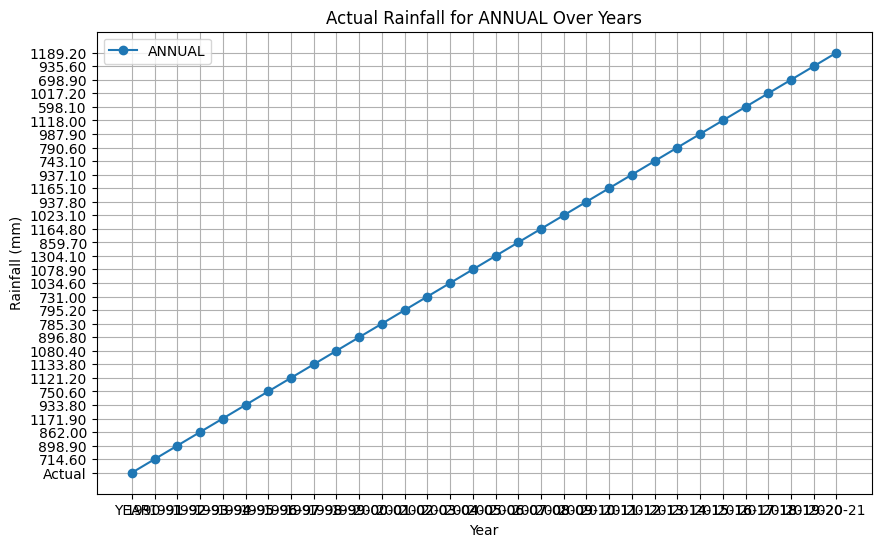

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'Rainfall.csv'  # Replace 'path_to_your_file.csv' with the actual file path
data = pd.read_csv(file_path)
data.set_index('TIME PERIOD', inplace=True)  # Set 'TIME PERIOD' as index

def plot_season(season):
    plt.figure(figsize=(10, 6))
    
    # Check if the selected season exists in the columns
    if season in data.columns:
        plt.plot(data.index, data[season], marker='o', label=season)
        plt.title(f'Actual Rainfall for {season} Over Years')
        plt.xlabel('Year')
        plt.ylabel('Rainfall (mm)')
        plt.legend()
        plt.grid(True)
        
        # Set y-axis range from 0 to the maximum rainfall value
        plt.ylim(0, data[season].max() + 20)
        
        plt.xticks(rotation=45)  # Rotate x-axis labels for readability
        plt.tight_layout()
        plt.show()
    else:
        print(f"Season '{season}' not found in the dataset.")

# Ask user to input the season
selected_season = input("Enter the season to visualize (SOUTH-WESTMONSOON, NORTH-EASTMONSOON, WINTER SEASON, SUMMER SEASON, ANNUAL): ")

# Plot the selected season
plot_season(selected_season)
